# Phase 5 — Results Analysis
**Longitudinal CBC Trend Analyzer**

This notebook visualises the trained model's performance on the held-out test set.

> **Prerequisites:** Run `train.py` then `phase5_part1_evaluate.py` first.

## 0. Imports & Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import warnings
import sys
import os
sys.path.append('..')
sys.path.append(os.path.abspath(''))   # current directory
os.chdir('/Users/jamespham/PycharmProjects/cbc_tracker')  # your project root
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('muted')

# Load evaluation results
with open('outputs/evaluation_results.json') as f:
    results = json.load(f)

# Load training history
with open('outputs/training_history.json') as f:
    history = json.load(f)

print('Results loaded.')
print(f"AUROC: {results['auroc']:.4f}  |  AUPRC: {results['auprc']:.4f}  |  "
      f"Sensitivity: {results['sensitivity']:.4f}  |  Specificity: {results['specificity']:.4f}")

Results loaded.
AUROC: 0.9603  |  AUPRC: 0.9164  |  Sensitivity: 0.7818  |  Specificity: 0.9664


## 1. Training Curves
Loss and AUROC over epochs for train and validation sets.

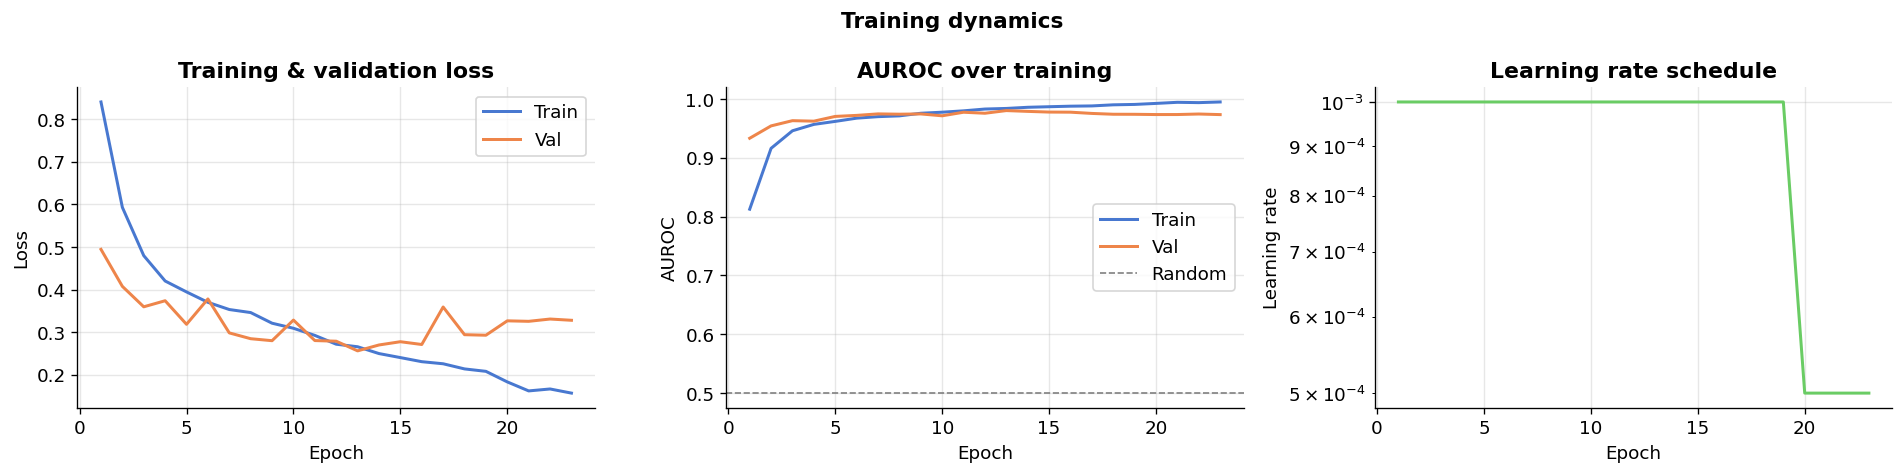

In [2]:
from pathlib import Path
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train', color=PALETTE[0], linewidth=1.8)
axes[0].plot(epochs, history['val_loss'],   label='Val',   color=PALETTE[1], linewidth=1.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & validation loss', fontweight='bold')
axes[0].legend()

# AUROC
axes[1].plot(epochs, history['train_auroc'], label='Train', color=PALETTE[0], linewidth=1.8)
axes[1].plot(epochs, history['val_auroc'],   label='Val',   color=PALETTE[1], linewidth=1.8)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC over training', fontweight='bold')
axes[1].legend()

# Learning rate
axes[2].plot(epochs, history['lr'], color=PALETTE[2], linewidth=1.8)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning rate')
axes[2].set_title('Learning rate schedule', fontweight='bold')
axes[2].set_yscale('log')

plt.suptitle('Training dynamics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/training_curves.png', bbox_inches='tight')
plt.show()

## 2. ROC & Precision-Recall Curves
The two most important diagnostic plots for a binary classifier.

- **ROC curve**: sensitivity vs (1-specificity). AUROC = 1.0 is perfect, 0.5 is random.
- **PR curve**: precision vs recall. More informative than ROC on imbalanced data because it focuses purely on the positive (anomaly) class.

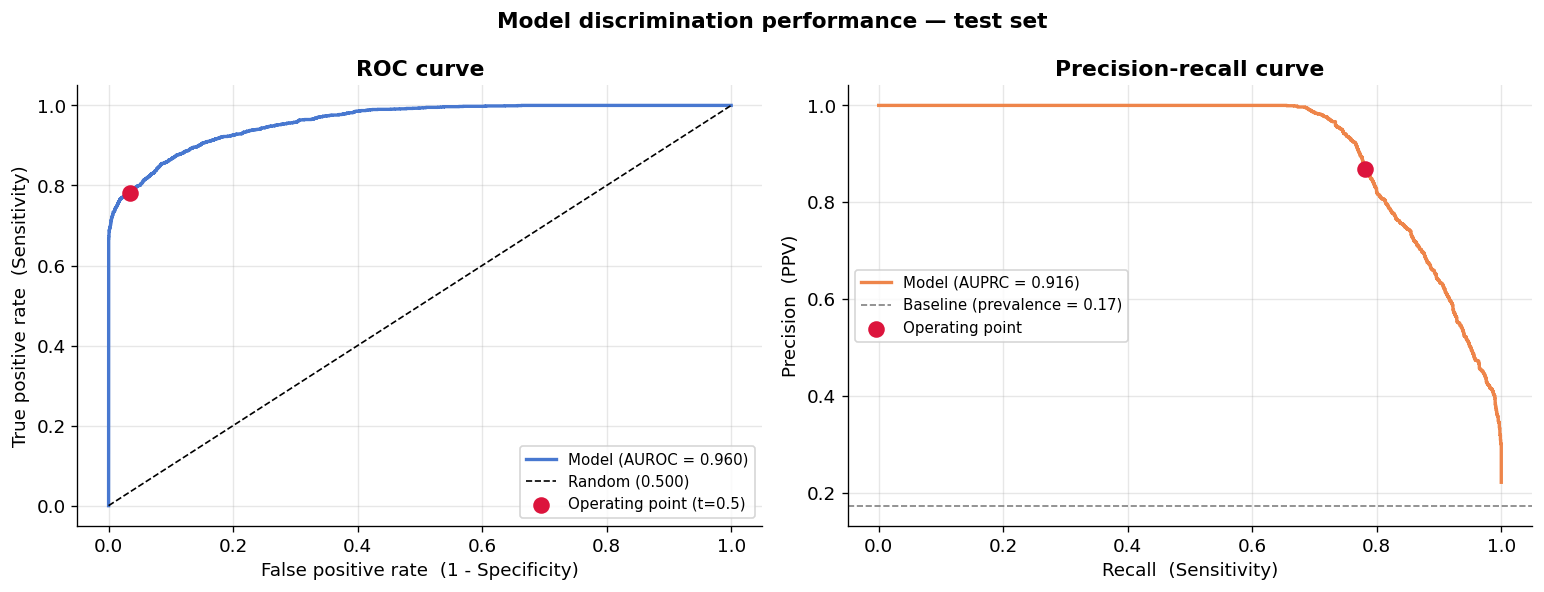

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr = results['fpr']
tpr = results['tpr']
axes[0].plot(fpr, tpr, color=PALETTE[0], linewidth=2,
             label=f"Model (AUROC = {results['auroc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.500)')
axes[0].scatter([1 - results['specificity']], [results['sensitivity']],
                color='crimson', zorder=5, s=80,
                label=f"Operating point (t={results['threshold']})")
axes[0].set_xlabel('False positive rate  (1 - Specificity)')
axes[0].set_ylabel('True positive rate  (Sensitivity)')
axes[0].set_title('ROC curve', fontweight='bold')
axes[0].legend(fontsize=9)

# PR
prec = results['precision']
rec  = results['recall']
baseline = results['tp'] / (results['tp'] + results['fn'] +
                             results['tn'] + results['fp'])
axes[1].plot(rec, prec, color=PALETTE[1], linewidth=2,
             label=f"Model (AUPRC = {results['auprc']:.3f})")
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (prevalence = {baseline:.2f})')
axes[1].scatter([results['sensitivity']], [results['ppv']],
                color='crimson', zorder=5, s=80,
                label=f"Operating point")
axes[1].set_xlabel('Recall  (Sensitivity)')
axes[1].set_ylabel('Precision  (PPV)')
axes[1].set_title('Precision-recall curve', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Model discrimination performance — test set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 3. Confusion Matrix

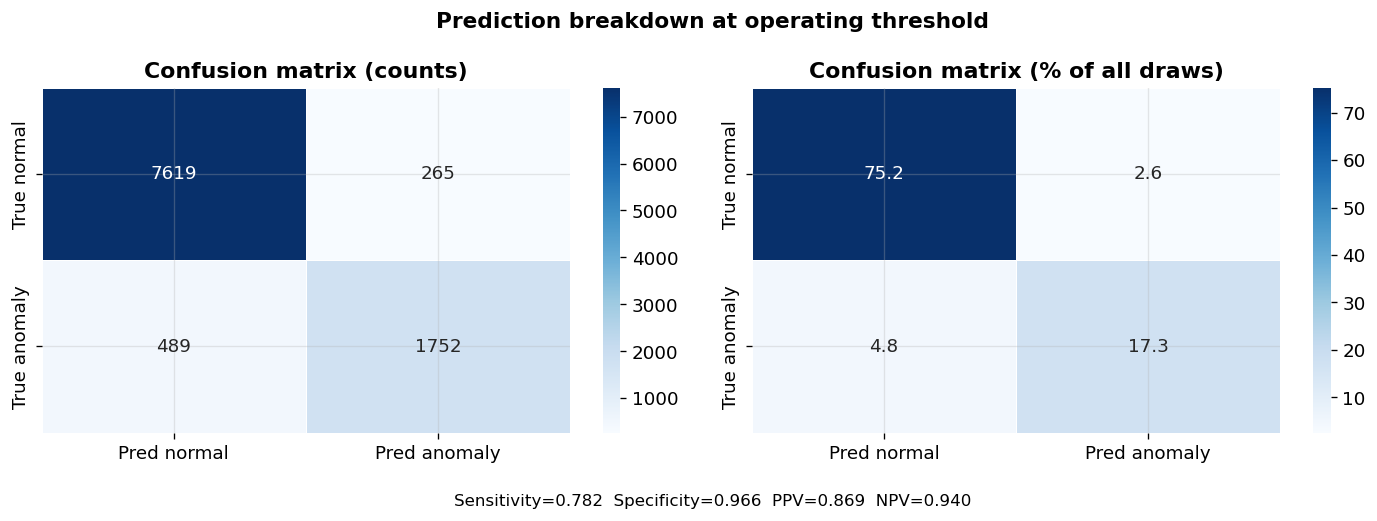

In [4]:
tp, tn = results['tp'], results['tn']
fp, fn = results['fp'], results['fn']
total  = tp + tn + fp + fn

cm = np.array([[tn, fp], [fn, tp]])
cm_pct = cm / total * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred normal', 'Pred anomaly'],
            yticklabels=['True normal', 'True anomaly'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion matrix (counts)', fontweight='bold')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Pred normal', 'Pred anomaly'],
            yticklabels=['True normal', 'True anomaly'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion matrix (% of all draws)', fontweight='bold')

# Clinical annotation
fig.text(0.5, -0.05,
         f"Sensitivity={results['sensitivity']:.3f}  "
         f"Specificity={results['specificity']:.3f}  "
         f"PPV={results['ppv']:.3f}  "
         f"NPV={results['npv']:.3f}",
         ha='center', fontsize=10)

plt.suptitle('Prediction breakdown at operating threshold', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. Score Distribution by Anomaly Type
Do the three anomaly types produce different score profiles?
A good model should score `sudden_drop` and `erratic` windows higher than `none`.

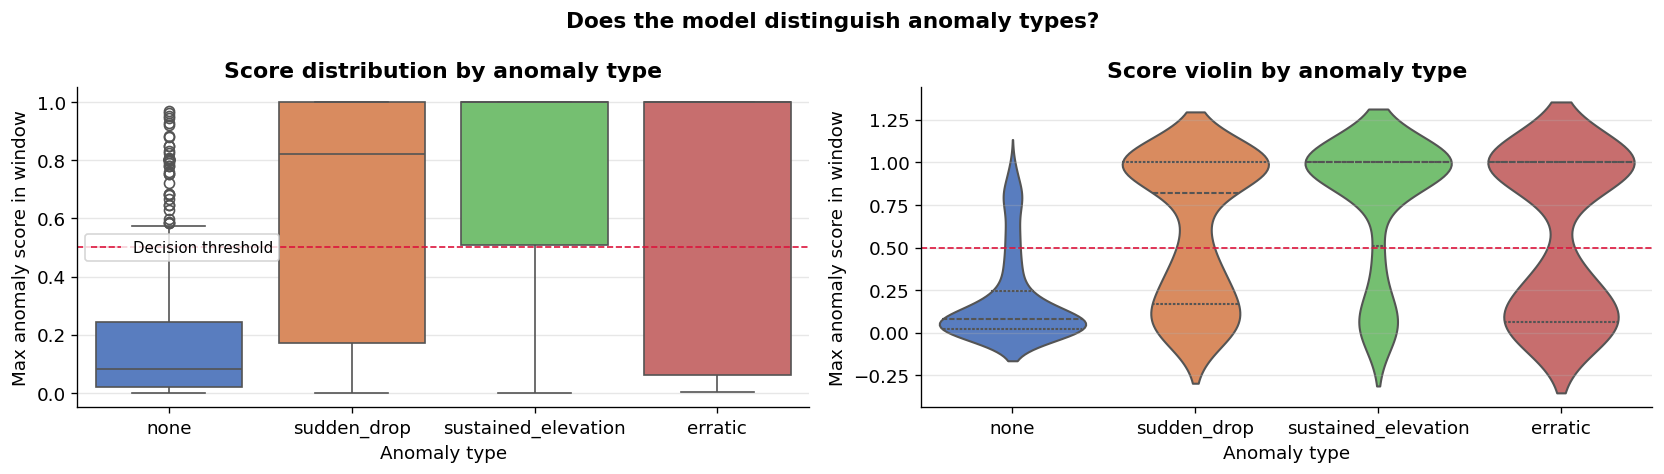

                     count   mean    std    min    25%    50%    75%   max
anomaly_type                                                              
erratic              105.0  0.572  0.450  0.002  0.063  1.000  1.000  1.00
none                 311.0  0.196  0.259  0.000  0.020  0.081  0.242  0.97
sudden_drop          170.0  0.606  0.414  0.000  0.172  0.821  1.000  1.00
sustained_elevation   89.0  0.774  0.385  0.001  0.509  1.000  1.000  1.00


In [5]:
ws = pd.DataFrame(results['window_scores'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot of max anomaly score per window by type
order = ['none', 'sudden_drop', 'sustained_elevation', 'erratic']
order = [o for o in order if o in ws['anomaly_type'].unique()]

sns.boxplot(data=ws, x='anomaly_type', y='max_score',
            order=order, palette='muted', ax=axes[0])
axes[0].axhline(0.5, color='crimson', linestyle='--', linewidth=1,
                label='Decision threshold')
axes[0].set_xlabel('Anomaly type')
axes[0].set_ylabel('Max anomaly score in window')
axes[0].set_title('Score distribution by anomaly type', fontweight='bold')
axes[0].legend(fontsize=9)

# Violin for richer view
sns.violinplot(data=ws, x='anomaly_type', y='max_score',
               order=order, palette='muted', ax=axes[1], inner='quartile')
axes[1].axhline(0.5, color='crimson', linestyle='--', linewidth=1)
axes[1].set_xlabel('Anomaly type')
axes[1].set_ylabel('Max anomaly score in window')
axes[1].set_title('Score violin by anomaly type', fontweight='bold')

plt.suptitle('Does the model distinguish anomaly types?', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/score_by_anomaly_type.png', bbox_inches='tight')
plt.show()

print(ws.groupby('anomaly_type')['max_score'].describe().round(3))

## 5. Sample Patient Timelines
The most clinically interpretable plot: anomaly score over time for individual patients,
overlaid on their actual CBC values.

Preprocessor loaded from outputs/preprocessor.pkl
Model weights loaded from outputs/checkpoints/best_model.pt
Running on: mps
Built 21 windows (skipped 0 patients with < 15 draws)
Built 6 windows (skipped 0 patients with < 15 draws)
Built 41 windows (skipped 0 patients with < 15 draws)
Built 23 windows (skipped 0 patients with < 15 draws)


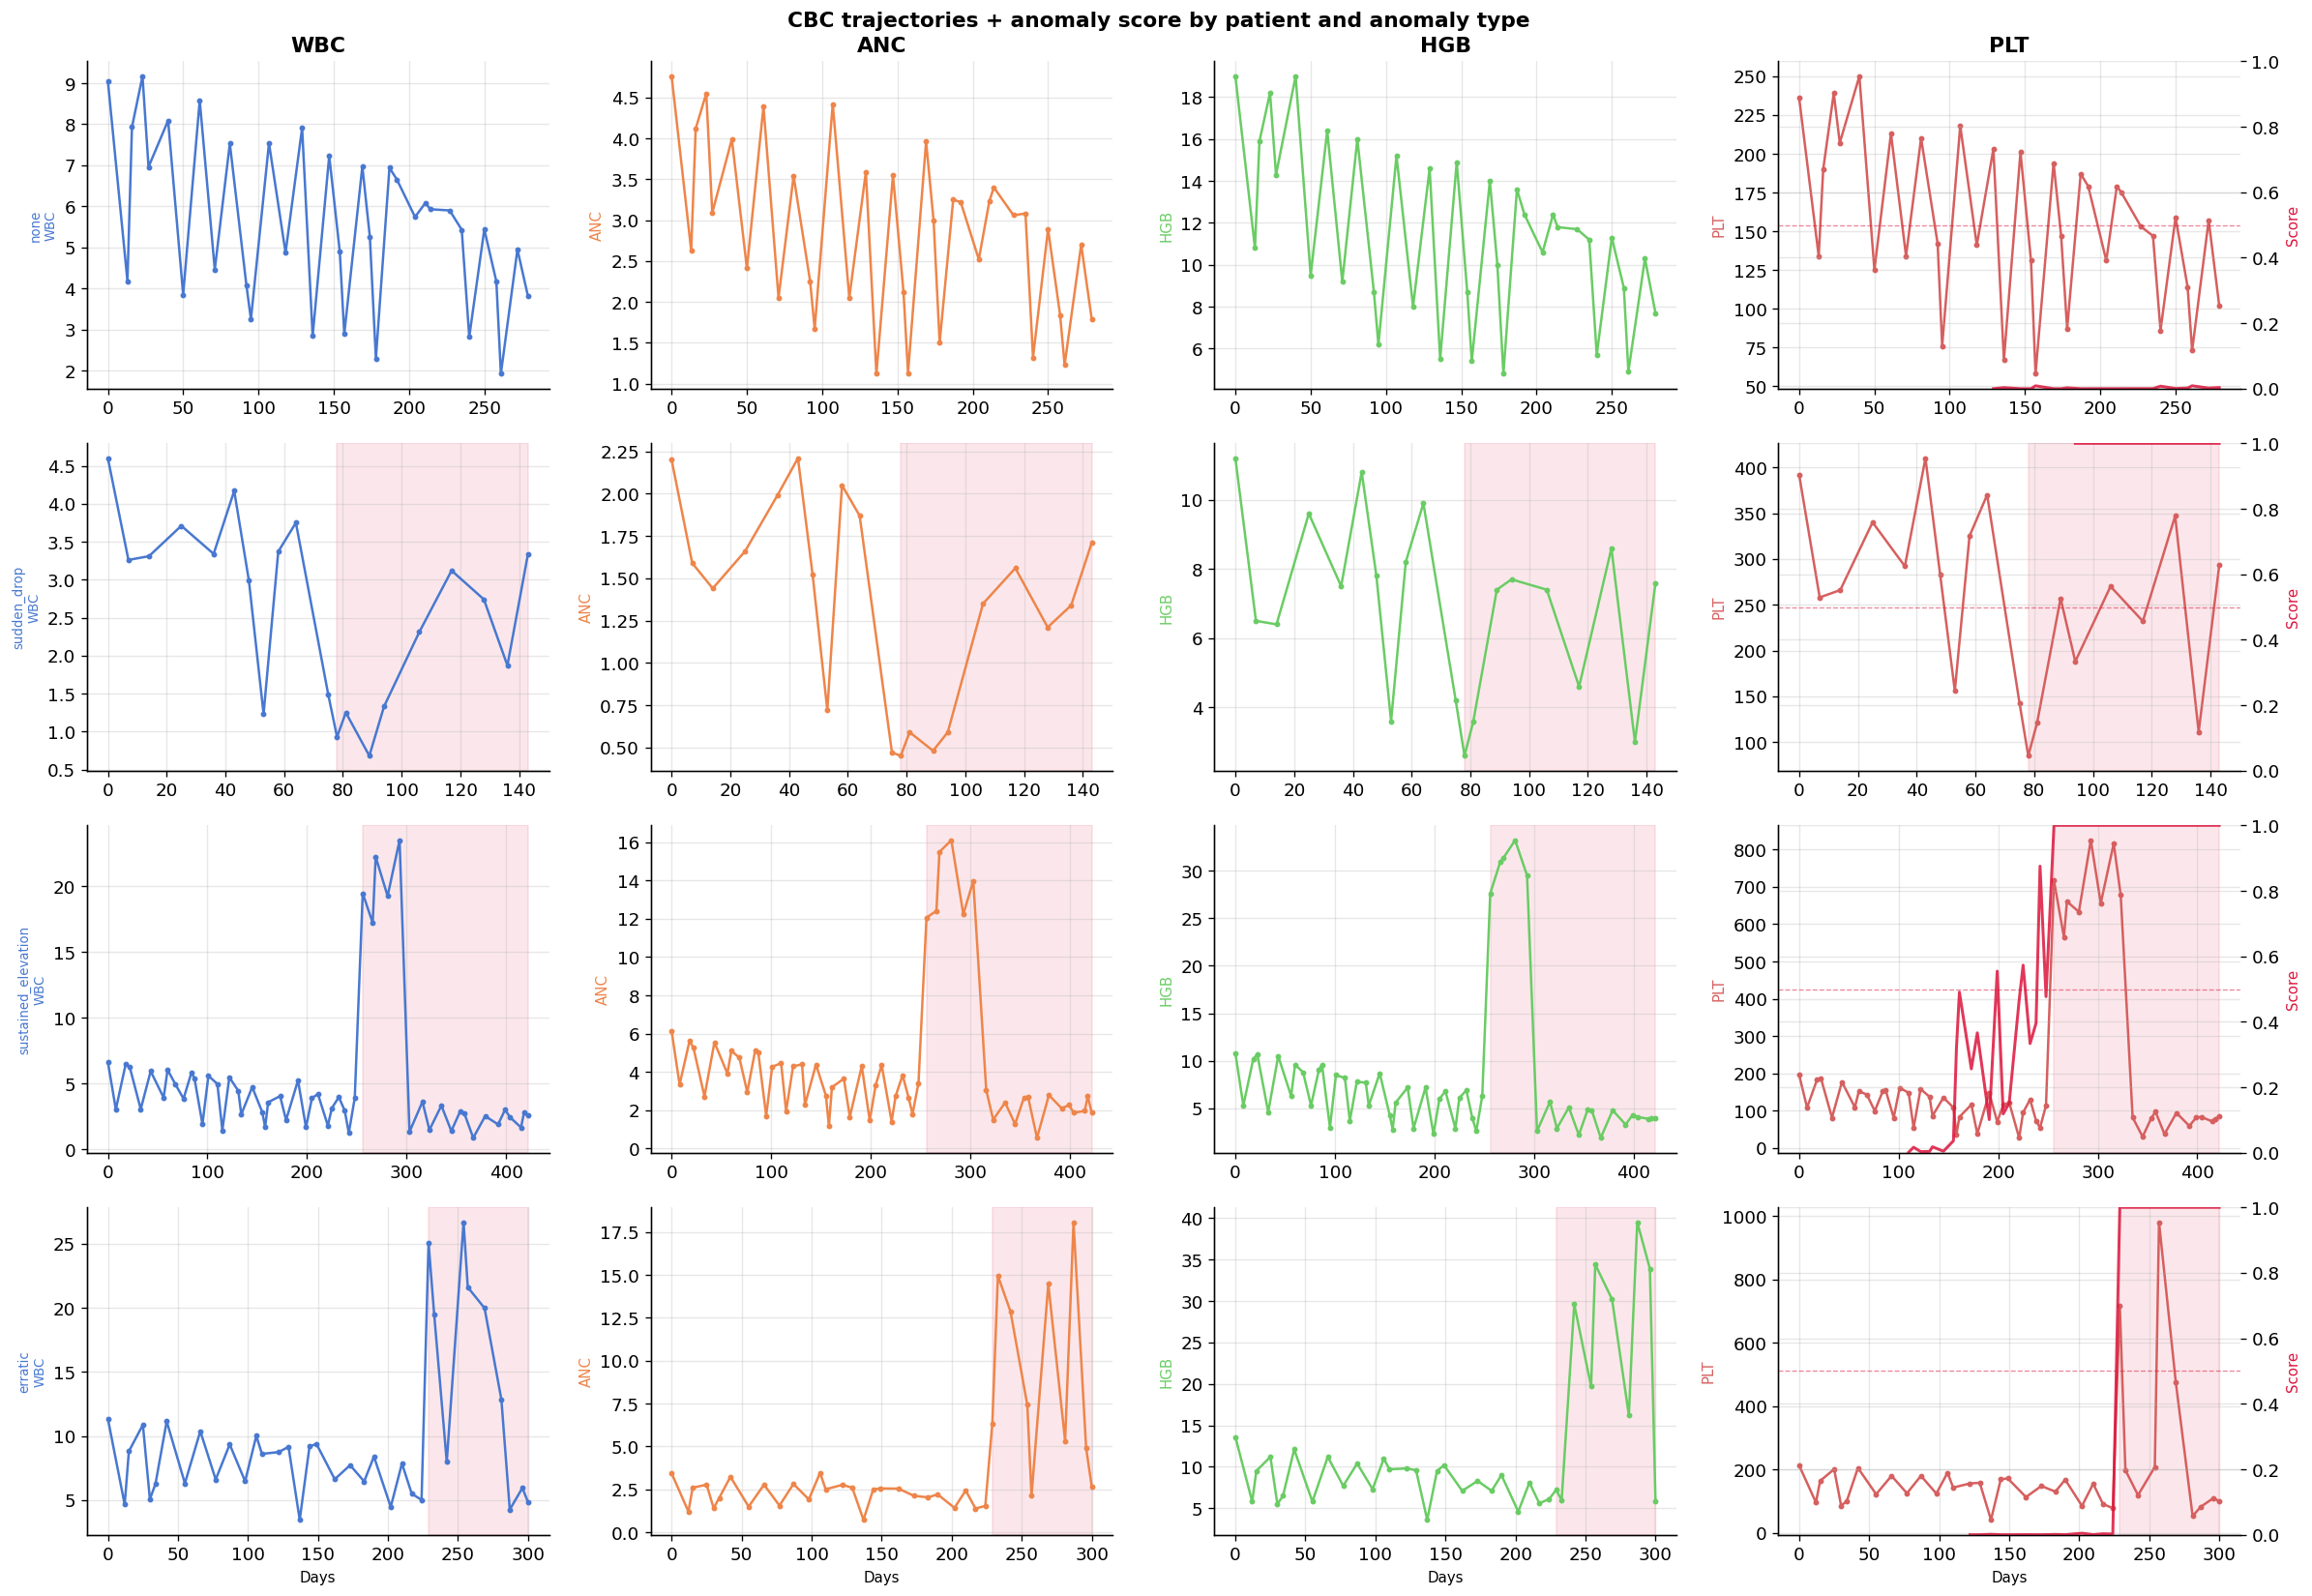

In [8]:
from phase2_preprocessing import CBCPreprocessor, build_windows, WINDOW_SIZE
from phase3_part4_full_model import CBCAnomalyTCN
from predict import load_inference_artifacts, predict_patient

model, preprocessor, device = load_inference_artifacts()
df = pd.read_csv('data/cbc_synthetic.csv')

FEATURES_TO_PLOT = ['WBC', 'ANC', 'HGB', 'PLT']
ANOM_TYPES = ['none', 'sudden_drop', 'sustained_elevation', 'erratic']

fig, axes = plt.subplots(len(ANOM_TYPES), len(FEATURES_TO_PLOT),
                          figsize=(20, 14))

for row, atype in enumerate(ANOM_TYPES):
    pid = df[df['anomaly_type'] == atype]['patient_id'].iloc[0]
    pt  = df[df['patient_id'] == pid].sort_values('timestamp_day')
    pred_df = predict_patient(pt, model, preprocessor, device)

    for col, feat in enumerate(FEATURES_TO_PLOT):
        ax  = axes[row, col]
        ax2 = ax.twinx()

        # True anomaly shading
        anom_mask = pt['is_anomaly'].values.astype(bool)
        if anom_mask.any():
            ax.axvspan(pt['timestamp_day'].values[anom_mask].min(),
                       pt['timestamp_day'].values[anom_mask].max(),
                       alpha=0.1, color='crimson')

        # CBC feature
        ax.plot(pt['timestamp_day'], pt[feat],
                color=PALETTE[col], linewidth=1.5,
                marker='o', markersize=2.5)
        ax.set_ylabel(feat, fontsize=9, color=PALETTE[col])

        # Anomaly score (only on rightmost column to avoid clutter)
        if col == len(FEATURES_TO_PLOT) - 1:
            scored = pred_df.dropna(subset=['anomaly_score'])
            ax2.plot(scored['timestamp_day'], scored['anomaly_score'],
                     color='crimson', linewidth=1.8, alpha=0.85)
            ax2.axhline(0.5, color='crimson', linestyle='--',
                        linewidth=0.8, alpha=0.5)
            ax2.set_ylim(0, 1)
            ax2.set_ylabel('Score', color='crimson', fontsize=9)
        else:
            ax2.set_yticks([])   # hide right axis on non-score columns

        if row == 0:
            ax.set_title(feat, fontweight='bold')
        if row == len(ANOM_TYPES) - 1:
            ax.set_xlabel('Days', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{atype}\n{feat}', fontsize=8)

plt.suptitle('CBC trajectories + anomaly score by patient and anomaly type',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/patient_timelines.png', bbox_inches='tight')
plt.show()

## 6. Clinical Metrics Summary Card

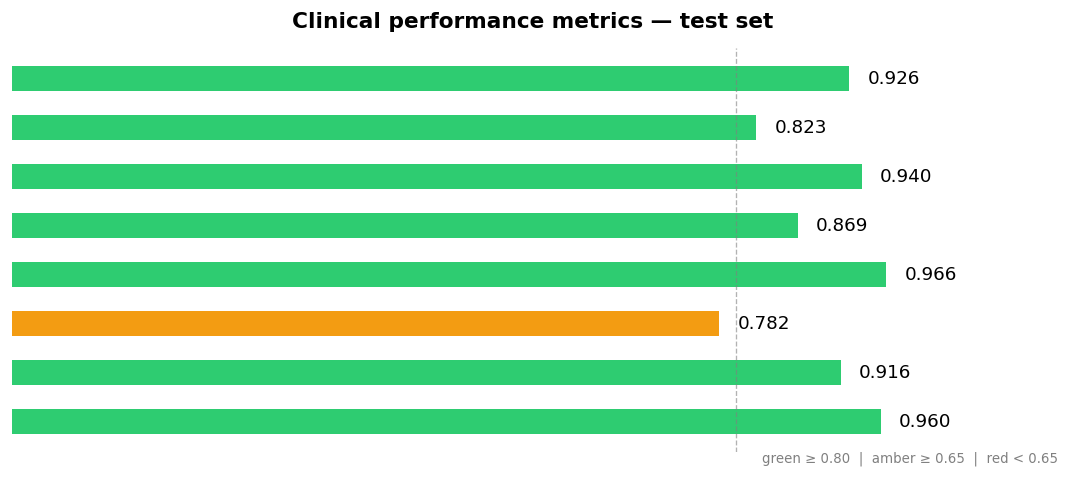

In [7]:
metrics = {
    'AUROC':       results['auroc'],
    'AUPRC':       results['auprc'],
    'Sensitivity': results['sensitivity'],
    'Specificity': results['specificity'],
    'PPV':         results['ppv'],
    'NPV':         results['npv'],
    'F1':          results['f1'],
    'Accuracy':    results['accuracy'],
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

names  = list(metrics.keys())
values = list(metrics.values())
colors = ['#2ecc71' if v >= 0.80
          else '#f39c12' if v >= 0.65
          else '#e74c3c'
          for v in values]

bars = ax.barh(names, values, color=colors, height=0.5, left=0)
ax.set_xlim(0, 1.15)
for bar, val in zip(bars, values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11)

ax.axvline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Clinical performance metrics — test set',
             fontweight='bold', fontsize=13, pad=12)

fig.text(0.85, 0.02, 'green ≥ 0.80  |  amber ≥ 0.65  |  red < 0.65',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('outputs/figures/metrics_summary.png', bbox_inches='tight')
plt.show()

## 7. Summary

| Component | File |
|---|---|
| Data generation | `phase1_generate_data.py` |
| Preprocessing | `phase2_preprocessing.py` |
| TCN block | `phase3_part1_temporal_block.py` |
| TCN backbone | `phase3_part2_tcn_backbone.py` |
| Static branch | `phase3_part3_static_branch.py` |
| Full model | `phase3_part4_full_model.py` |
| Loss function | `phase4_part1_loss.py` |
| Training loop | `phase4_part2_training_loop.py` |
| Training entry point | `train.py` |
| Evaluation | `phase5_part1_evaluate.py` |
| Inference | `predict.py` |

**Next extensions to consider:**
- SHAP values for explainability (which CBC features drove each alert?)
- Threshold tuning — optimise for sensitivity at fixed specificity (e.g. 90%)
- Multi-task head — add relapse classification alongside anomaly detection
- Real data validation on MIMIC-IV